In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import time
from tqdm import tqdm

total_start = time.time()
# Directory = r'D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing'
# os.chdir(Directory)
pwd = os.getcwd()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

REPO_ROOT = Path(pwd).resolve().parents[1]
WORKDIR = REPO_ROOT / "scripts" / "RingMod_Squeezing"
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_RingMod_Squeezing"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing
Data will be saved to: D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing


In [2]:
neff = 1.5277
L = 2 * np.pi * 60E-6 
lambda0 = 1550E-9

M = int(neff * L / lambda0)
print("M =", M)

M = 371


In [3]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'RingHalf_gap_sweep.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


In [4]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1525E-9
LambdaStop     = 1575E-9

Width          = 1500E-9
Height         = 200E-9
Radius         = 100E-6
Gap            = 600E-9
Length         = 4 * Radius
YLength        = Radius
Material       = "Si3N4 (Silicon Nitride) - Luke"
CouplingLength = 0.0E-6
Index          = 2; #optional
decay_time     = 1E-7

BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 1200E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(2000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 100000


Mode numbers: [371]
Relative μ: [0]
Amplitudes (nm): [0.]
Minimum radius: 1.50 µm
Maximum radius: 1.50 µm
Ring Area: 942.48 µm²
Modulated Ring Area: 942.48 µm²
Area Difference due to modulation: 0.00 µm²


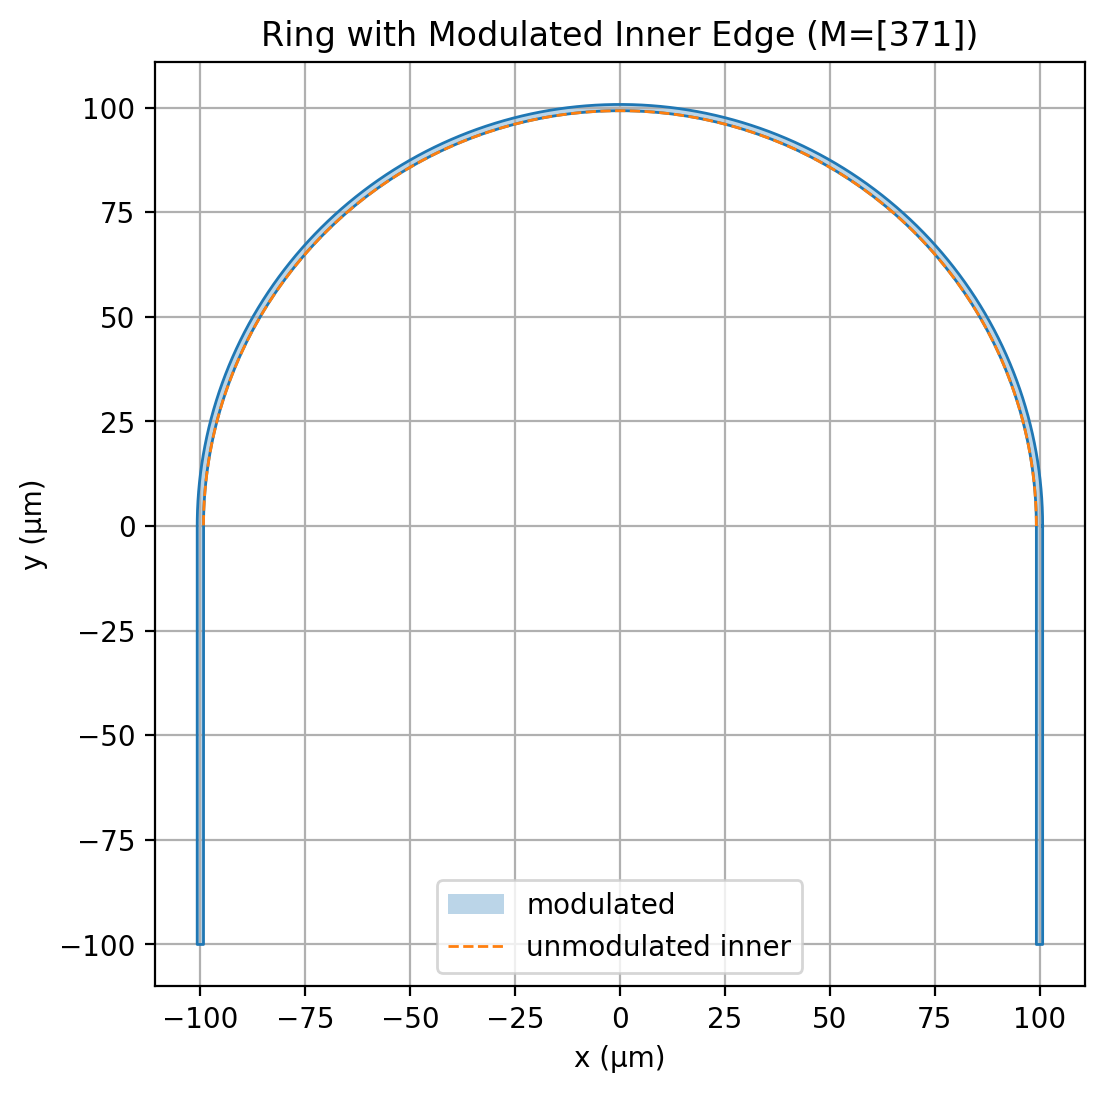

Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.


In [5]:
# --- Mode number tracking ---------------

M_ref = 371 # Mode numbers (using 300 as reference μ=0)
# M     = np.array(np.linspace(370,373,2))
M = [371]  # Mode numbers to be modulated
mu    = np.array(M) - M_ref  # Relative mode numbers: [1, 2, 5, 10, 20]
print(f"Mode numbers: {M}")
print(f"Relative μ: {mu}")

# --- Amplitude of modulation ---------------

A_max = 0E-9
# A = A_max*(abs(mu)/np.max(mu))**2  # Amplitude of modulation
A = A_max*np.ones_like(mu)     # Amplitude of modulation
print(f"Amplitudes (nm): {A*1e9}")
Npoints = max(5000, 300*M_ref)  # Number of points for smoothness
Npoints = 1000

#--- Modulated Ring Generation --------------

def generate_half_ring_with_length(Radius=4e-6,
                                    width=700e-9,
                                    A=300e-9,
                                    M=50,
                                    Npoints=1000,length_extra=Length):
    theta         = np.linspace(0, np.pi, Npoints)
    R_inner_base  = Radius - width/2
    R_outer_base  = Radius + width/2

    # ensure A_list, M_list
    A_list = np.atleast_1d(A)
    M_list = np.atleast_1d(M)

    # sum of cosines
    modulation = np.zeros_like(theta)
    for i, (Ai, Mi) in enumerate(zip(A_list, M_list)):
        
        if Mi == 0:
            # No modulation for M=0
            modulation += Ai
        else:
            # Normalized modulation
            # modulation += Ai * (np.cos(2*Mi * theta + (2*np.pi/ (i+1))))
            modulation += Ai * np.cos(2*Mi * theta + (2*np.pi/len(M_list))*i)

    R_inner       = R_inner_base - modulation
    R_outer_const = R_outer_base
    
    min_radius = np.min(R_outer_const-R_inner)
    print(f"Minimum radius: {min_radius*1e6:.2f} µm")
    
    max_radius = np.max(R_outer_const-R_inner)
    print(f"Maximum radius: {max_radius*1e6:.2f} µm")

    RingArea = np.pi * (R_outer_const**2 - R_inner_base**2)
    print(f"Ring Area: {RingArea*1e12:.2f} µm²")
    
    ModRingArea = np.pi * (R_outer_const**2 - np.mean(R_inner**2))
    print(f"Modulated Ring Area: {ModRingArea*1e12:.2f} µm²")
    
    AreaDiff = ModRingArea - RingArea
    print(f"Area Difference due to modulation: {AreaDiff*1e12:.2f} µm²")
    L_strain = length_extra
    # Outer arc θ=0→π (not reversed)
    x_outer = R_outer_base * np.cos(theta)
    y_outer = R_outer_base * np.sin(theta)

    # Left wg: down and back up
    left_wg_x = np.array([-R_outer_base, -R_outer_base, -R_inner_base, -R_inner_base])
    left_wg_y = np.array([0, -L_strain, -L_strain, 0])

    # Inner arc θ=π→0 (reversed)
    x_inner = R_inner * np.cos(theta[::-1])  
    y_inner = R_inner * np.sin(theta[::-1])

    # Right wg: down and back up
    right_wg_x = np.array([R_inner_base, R_inner_base, R_outer_base, R_outer_base])
    right_wg_y = np.array([0, -L_strain, -L_strain, 0])

    x_poly = np.concatenate([x_outer, left_wg_x, x_inner, right_wg_x])
    y_poly = np.concatenate([y_outer, left_wg_y, y_inner, right_wg_y])

    return x_poly, y_poly

x_poly, y_poly = generate_half_ring_with_length(Radius=Radius ,
                                            width=Width, A = A, M=M, Npoints=Npoints, length_extra=YLength)
# compute unmodulated inner ring
theta_base   = np.linspace(0, np.pi, Npoints)
R_inner_base = Radius - Width/2
x_base       = R_inner_base * np.cos(theta_base)
y_base       = R_inner_base * np.sin(theta_base)

# visualize
plt.figure(figsize=(6,6))
plt.fill(x_poly*1e6, y_poly*1e6, alpha=0.3, label='modulated')
plt.plot(x_poly*1e6, y_poly*1e6, '-', linewidth=1)
plt.plot(x_base*1e6, y_base*1e6, '--', linewidth=1, label='unmodulated inner')
plt.axis('equal')
plt.gcf().set_dpi(200)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Ring with Modulated Inner Edge (M={M})')
plt.legend()
plt.grid()

# Save figure as high-res PNG for zooming in
plt.savefig("modulated_ring_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.")


🚀 Starting Gap Sweep | 13 points



Gap Sweep:   0%|                                         | 0/13 [00:00<?, ?it/s]


--- Gap 1/13: 50 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 139.7s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.865861965516458, Tx through at 1550 = 0.11694462734454897
gap=50.00nm | η=88.10% | Loss=0.08dB


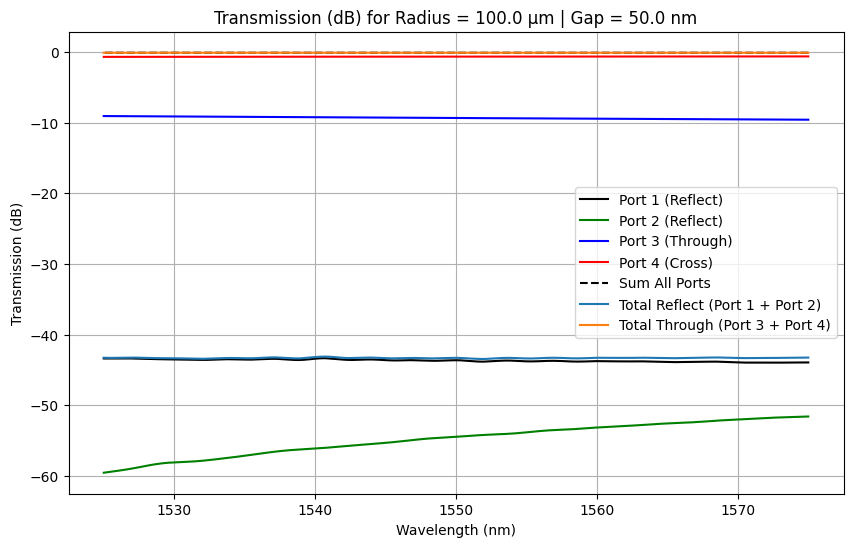

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap50.00nm_Tx.txt


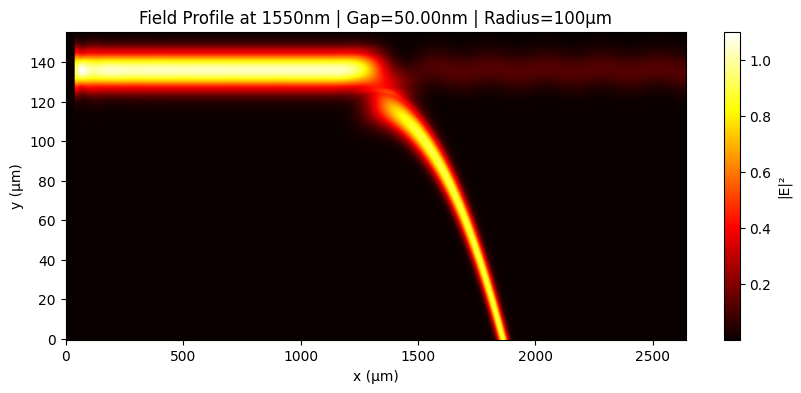

Gap Sweep:   8%|██▍                             | 1/13 [02:22<28:30, 142.55s/it]

🎉 Gap 50.0 nm complete!

--- Gap 2/13: 75 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.2s
🏃 Running simulation... ✅ 151.0s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.8387719336769605, Tx through at 1550 = 0.1440778949034859
gap=75.00nm | η=85.34% | Loss=0.08dB


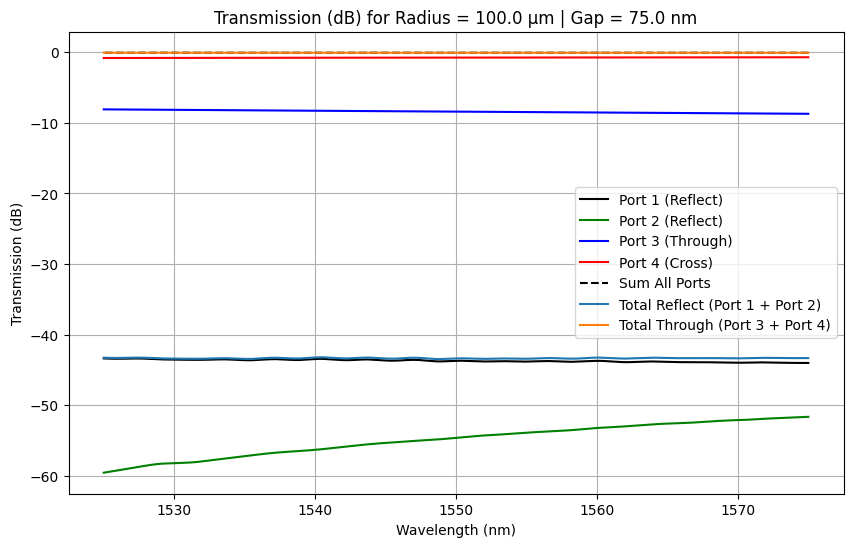

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap75.00nm_Tx.txt


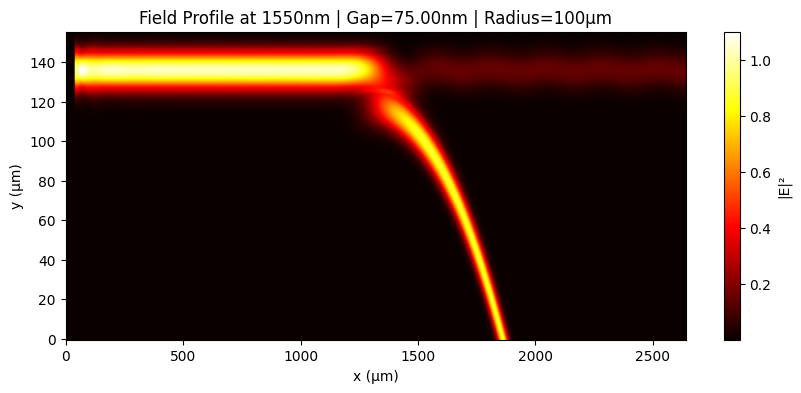

Gap Sweep:  15%|████▉                           | 2/13 [04:56<27:21, 149.22s/it]

🎉 Gap 75.0 nm complete!

--- Gap 3/13: 125 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 148.2s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.7686177426750171, Tx through at 1550 = 0.21434271714126715
gap=125.00nm | η=78.19% | Loss=0.07dB


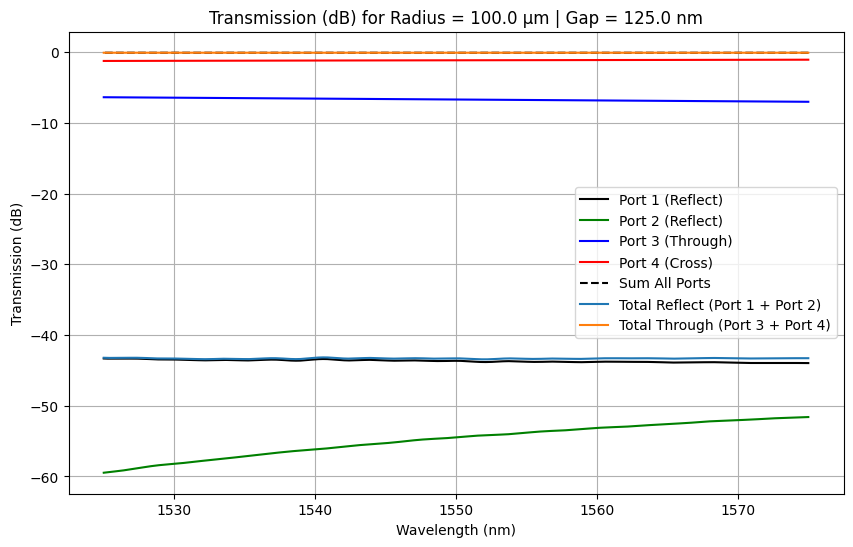

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap125.00nm_Tx.txt


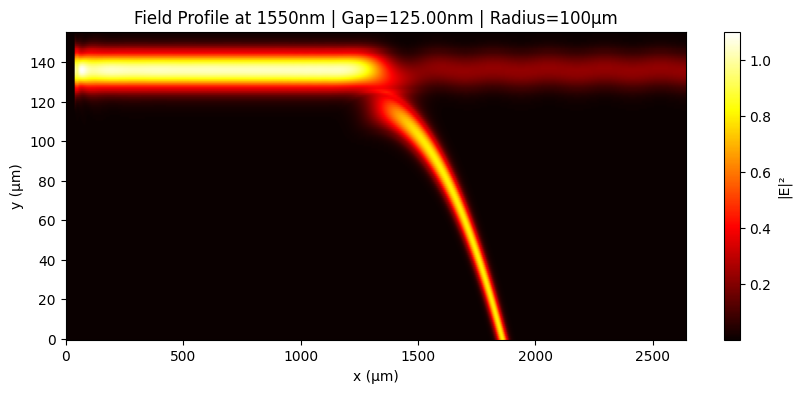

Gap Sweep:  23%|███████▍                        | 3/13 [07:27<25:00, 150.06s/it]

🎉 Gap 125.0 nm complete!

--- Gap 4/13: 150 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 140.9s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.7286372658628901, Tx through at 1550 = 0.254392590319019
gap=150.00nm | η=74.12% | Loss=0.07dB


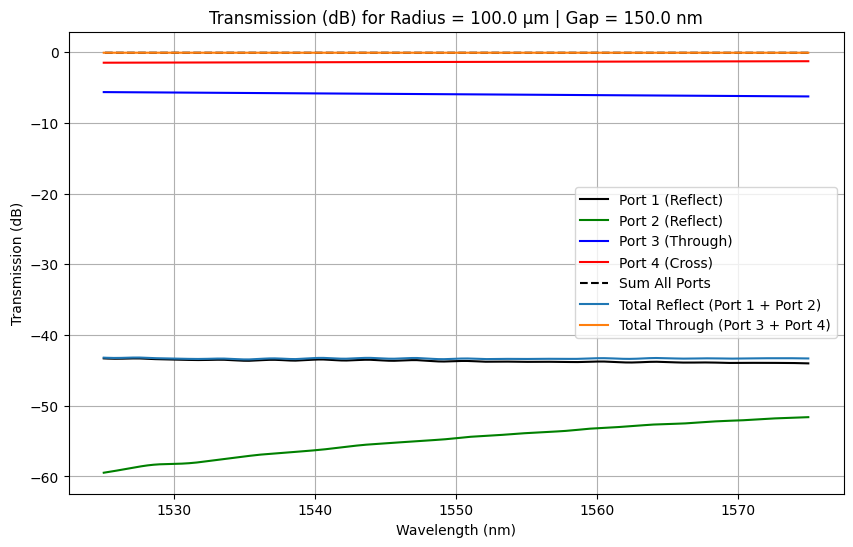

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap150.00nm_Tx.txt


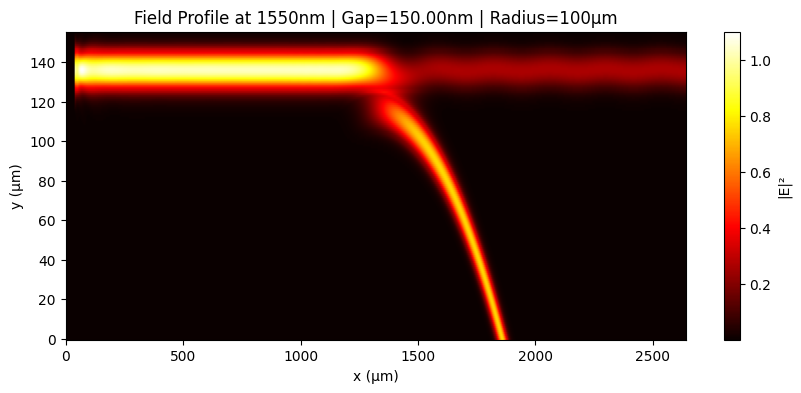

Gap Sweep:  31%|█████████▊                      | 4/13 [09:51<22:08, 147.60s/it]

🎉 Gap 150.0 nm complete!

--- Gap 5/13: 200 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 147.6s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.6443797418506733, Tx through at 1550 = 0.33879149247196816
gap=200.00nm | η=65.54% | Loss=0.07dB


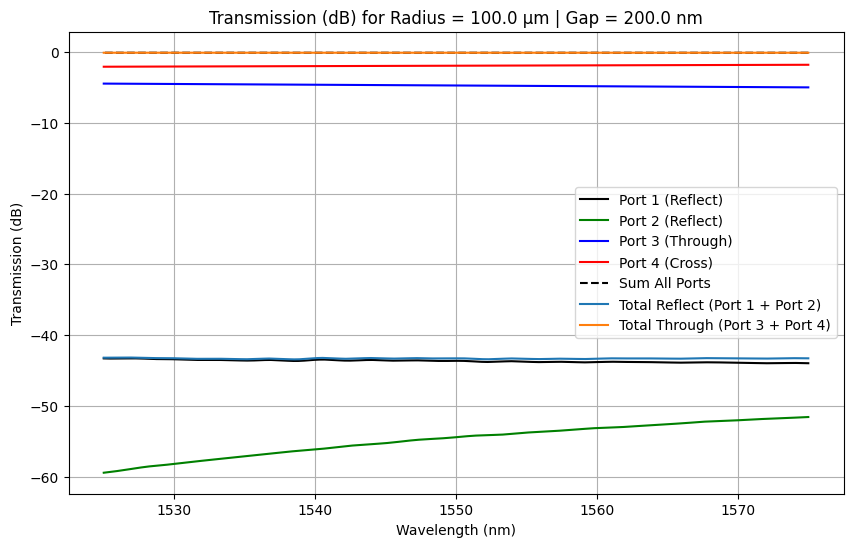

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap200.00nm_Tx.txt


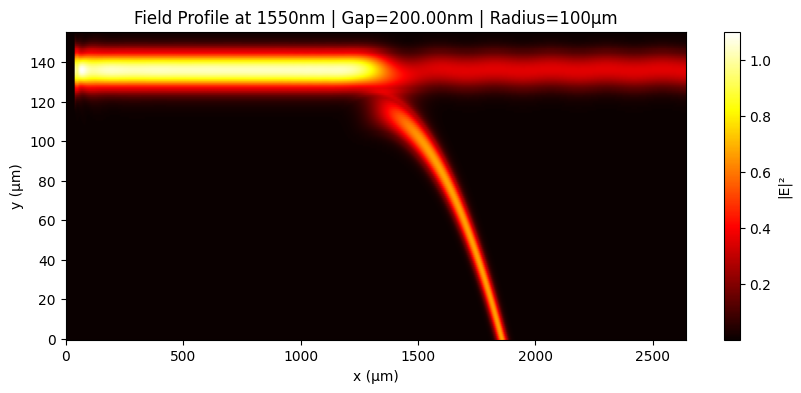

Gap Sweep:  38%|████████████▎                   | 5/13 [12:21<19:48, 148.61s/it]

🎉 Gap 200.0 nm complete!

--- Gap 6/13: 300 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.5s
🏃 Source & Monitors... ✅ 1.2s
🏃 Running simulation... ✅ 128.7s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.48074154311500084, Tx through at 1550 = 0.5027309676410269
gap=300.00nm | η=48.88% | Loss=0.07dB


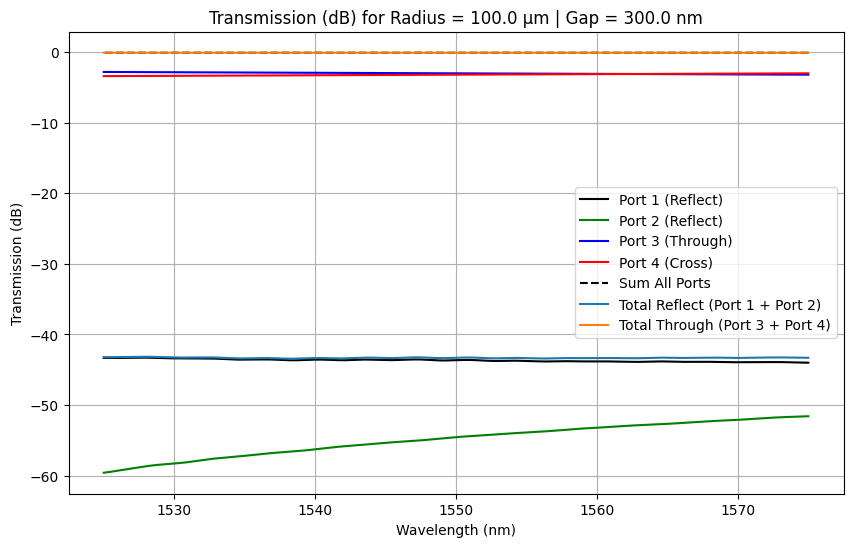

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap300.00nm_Tx.txt


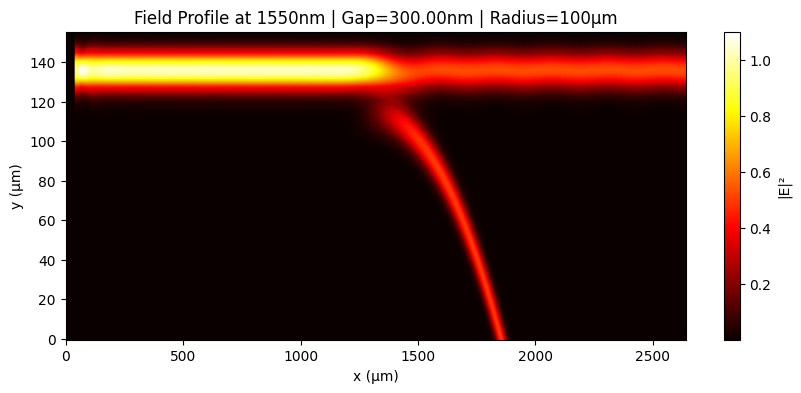

Gap Sweep:  46%|██████████████▊                 | 6/13 [14:33<16:39, 142.84s/it]

🎉 Gap 300.0 nm complete!

--- Gap 7/13: 400 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 129.7s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.34349016246948655, Tx through at 1550 = 0.6402159667596128
gap=400.00nm | η=34.92% | Loss=0.07dB


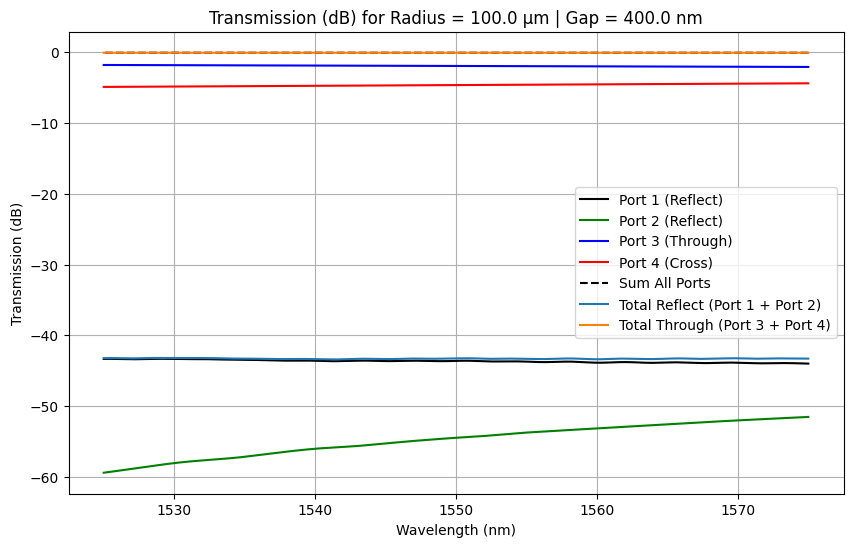

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap400.00nm_Tx.txt


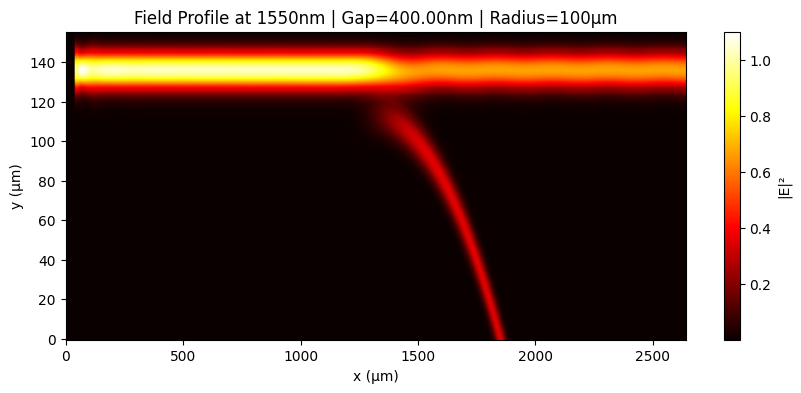

Gap Sweep:  54%|█████████████████▏              | 7/13 [16:45<13:56, 139.49s/it]

🎉 Gap 400.0 nm complete!

--- Gap 8/13: 500 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 129.0s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.2384521901544506, Tx through at 1550 = 0.7454832933755209
gap=500.00nm | η=24.23% | Loss=0.07dB


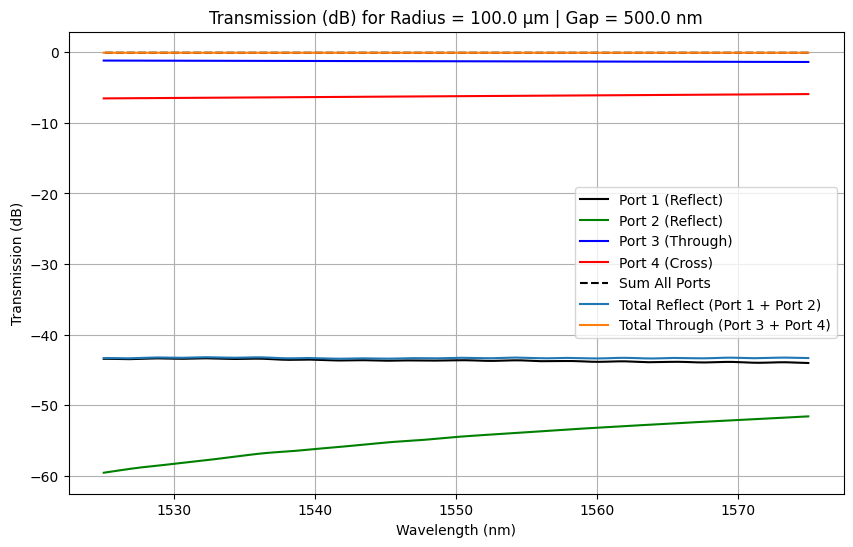

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap500.00nm_Tx.txt


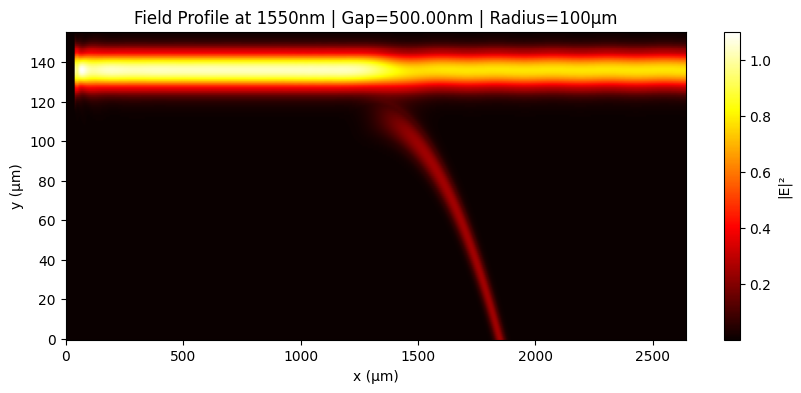

Gap Sweep:  62%|███████████████████▋            | 8/13 [18:57<11:25, 137.05s/it]

🎉 Gap 500.0 nm complete!

--- Gap 9/13: 600 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 127.0s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.16256933943571122, Tx through at 1550 = 0.8215437269876703
gap=600.00nm | η=16.52% | Loss=0.07dB


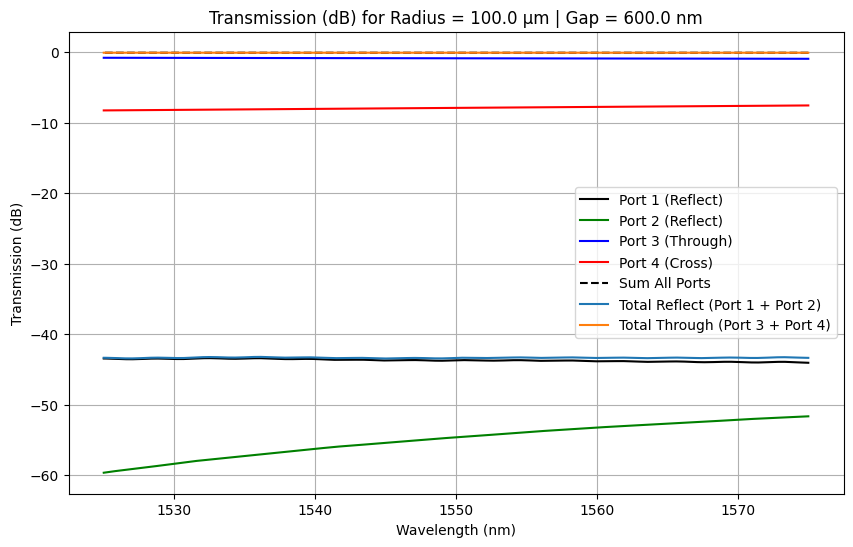

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap600.00nm_Tx.txt


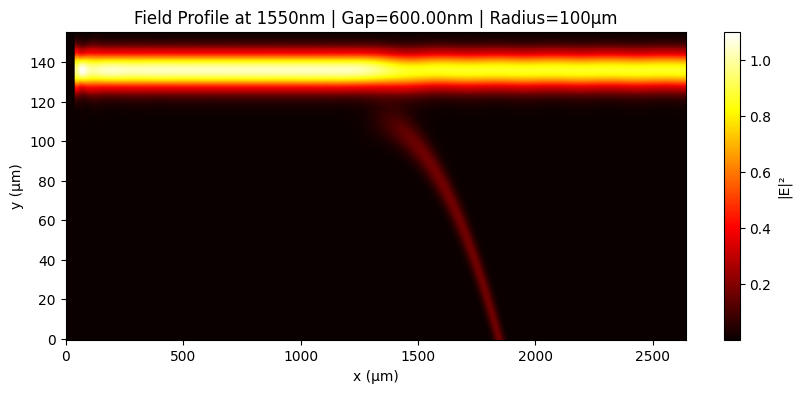

Gap Sweep:  69%|██████████████████████▏         | 9/13 [21:07<08:59, 134.80s/it]

🎉 Gap 600.0 nm complete!

--- Gap 10/13: 700 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 123.9s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.1096548725211311, Tx through at 1550 = 0.876008462786799
gap=700.00nm | η=11.12% | Loss=0.06dB


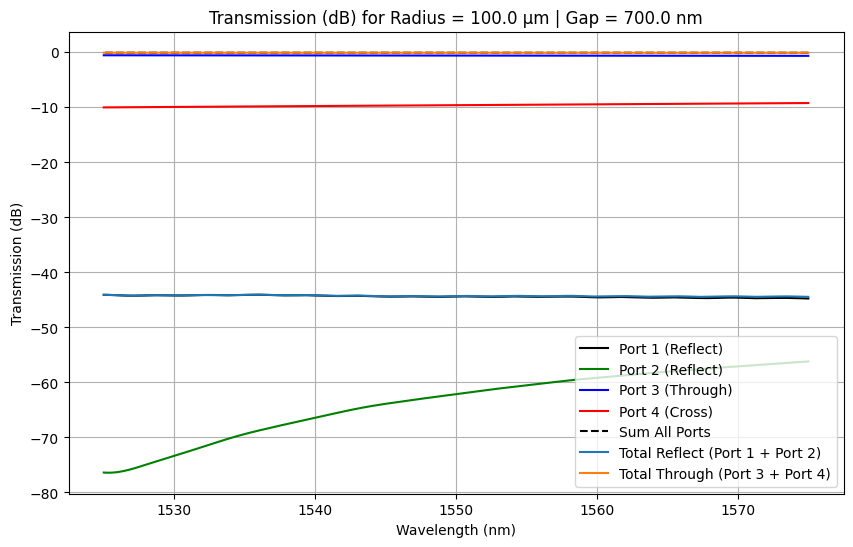

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap700.00nm_Tx.txt


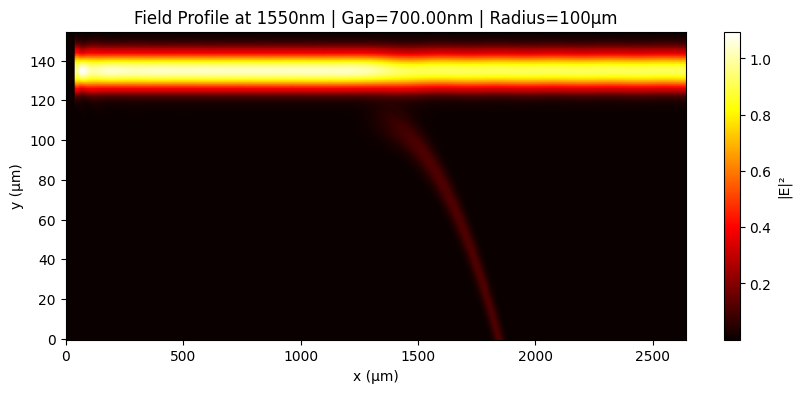

Gap Sweep:  77%|███████████████████████▊       | 10/13 [23:14<06:37, 132.42s/it]

🎉 Gap 700.0 nm complete!

--- Gap 11/13: 800 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 120.8s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.07311420661278346, Tx through at 1550 = 0.9105171166322884
gap=800.00nm | η=7.43% | Loss=0.07dB


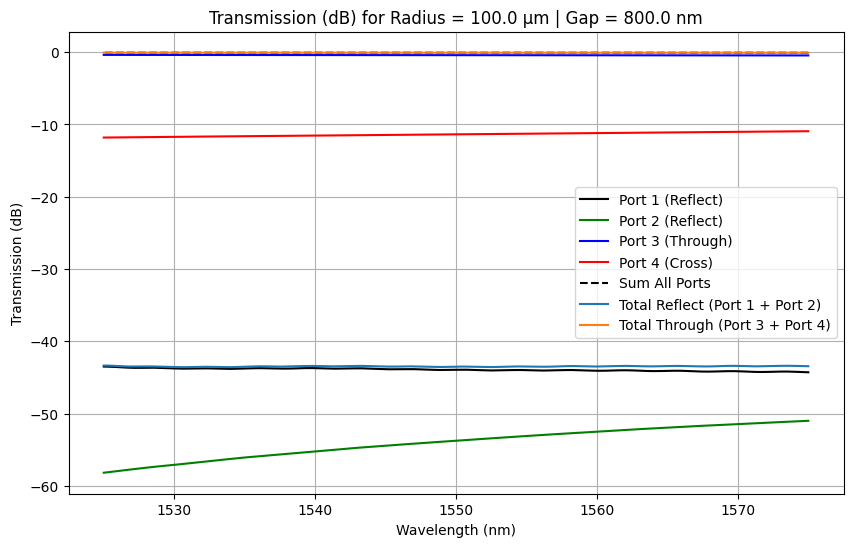

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap800.00nm_Tx.txt


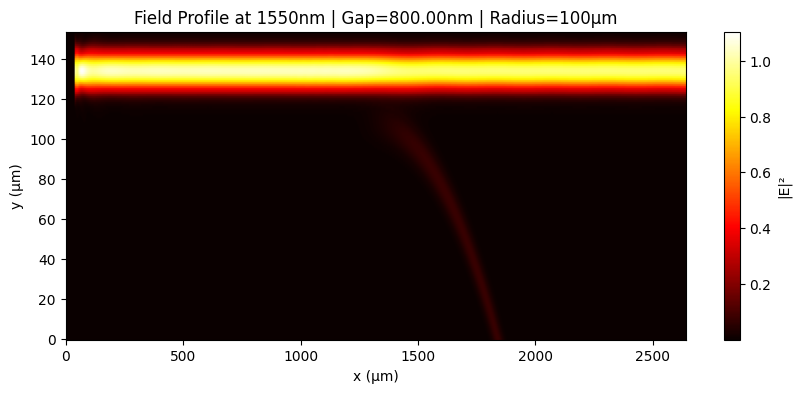

Gap Sweep:  85%|██████████████████████████▏    | 11/13 [25:18<04:19, 129.78s/it]

🎉 Gap 800.0 nm complete!

--- Gap 12/13: 900 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 120.7s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.048563718366612274, Tx through at 1550 = 0.9351538359341067
gap=900.00nm | η=4.94% | Loss=0.07dB


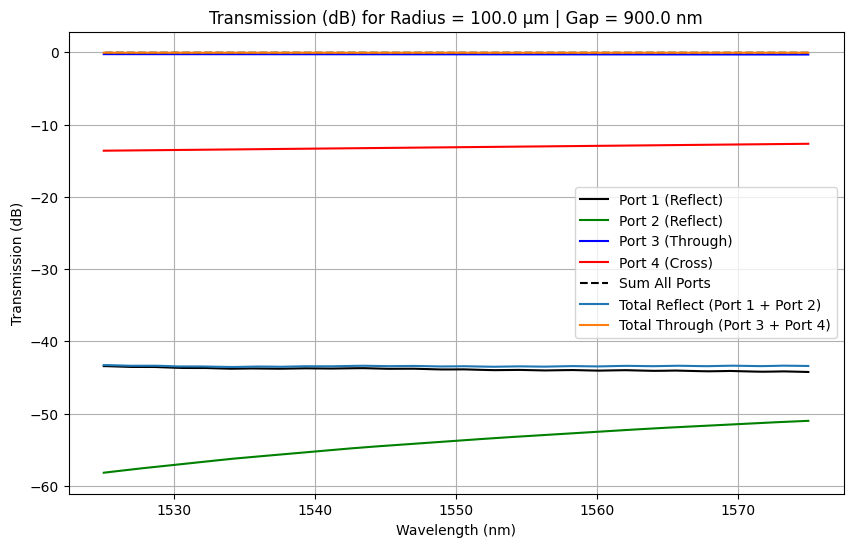

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap900.00nm_Tx.txt


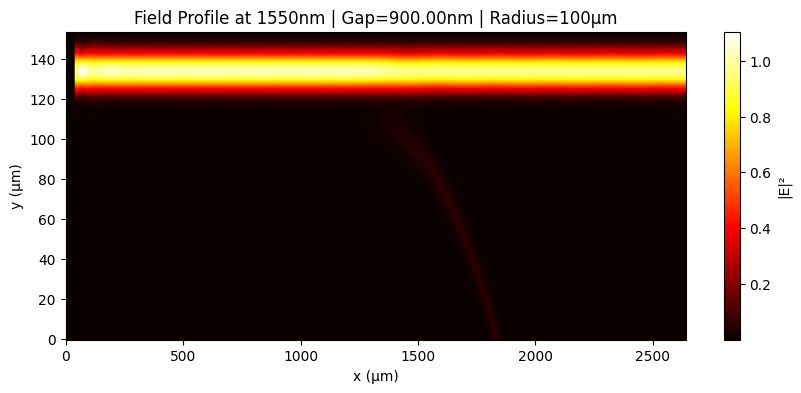

Gap Sweep:  92%|████████████████████████████▌  | 12/13 [27:22<02:07, 127.88s/it]

🎉 Gap 900.0 nm complete!

--- Gap 13/13: 1000 nm ---
🏃 Geometry setup... ✅ 0.2s
🏃 VarFDTD setup... ✅ 0.4s
🏃 Source & Monitors... ✅ 1.1s
🏃 Running simulation... ✅ 121.9s
🏃 Analysis & Save... index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.03214359981841099, Tx through at 1550 = 0.9516349694391041
gap=1000.00nm | η=3.27% | Loss=0.07dB


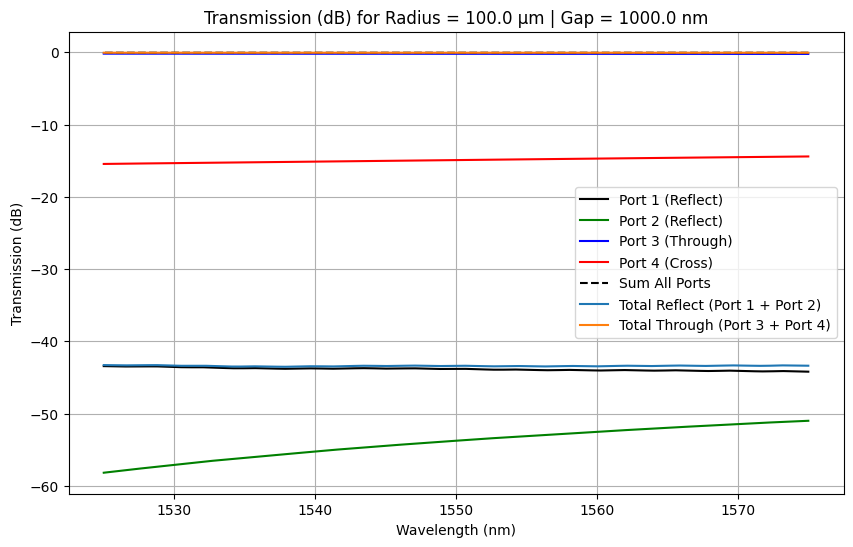

Data saved to D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing\Data_RingHalf_gap_sweep_radius100.0um_gap1000.00nm_Tx.txt


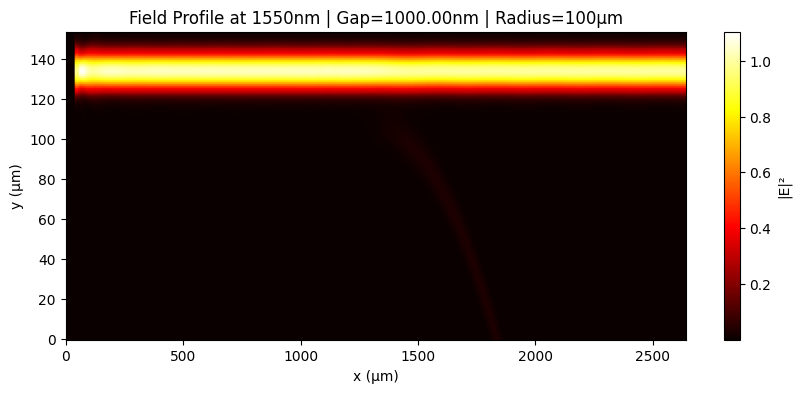

Gap Sweep: 100%|███████████████████████████████| 13/13 [29:26<00:00, 135.91s/it]

🎉 Gap 1000.0 nm complete!

⏱️ Total time: 29.5 min

🏆 All 13 sweeps complete!
       Gap  eta_1550(%)  loss_dB_1550  eta_variation(%)
0     50.0    88.100952      0.075319          1.414003
1     75.0    85.340803      0.075128          2.106954
2    125.0    78.194167      0.074640          3.220289
3    150.0    74.121580      0.074333          3.635870
4    200.0    65.540947      0.073708          4.209016
5    300.0    48.882052      0.072378          4.507754
6    400.0    34.917965      0.071346          4.108896
7    500.0    24.234535      0.070334          3.421479
8    600.0    16.519376      0.069550          2.692912
9    700.0    11.124982      0.062714          2.035321
10   800.0     7.433091      0.071676          1.506228
11   900.0     4.936754      0.071296          1.092313
12  1000.0     3.267361      0.071026          0.781454


In [6]:
def start_section(name):
    print(f"🏃 {name}...", end=" ", flush=True)
    return time.time()

def end_section(start):
    print(f"✅ {time.time() - start:.1f}s")

gaps = [50e-9,75e-9,125e-9,150e-9,200e-9, 300e-9, 400e-9, 500e-9, 600e-9,700e-9,800e-9,900e-9,1000e-9]  # start below current
# coupling_lengths = [10e-6]
gap_sweep_results = []

print(f"\n{'='*50}")
print(f"🚀 Starting Gap Sweep | {len(gaps)} points")
print(f"{'='*50}\n")

for i, g in enumerate(tqdm(gaps, desc="Gap Sweep", ncols=80)):
    Gap = g
    print(f"\n--- Gap {i+1}/{len(gaps)}: {Gap*1e9:.0f} nm ---")

    t = start_section("Geometry setup")
    f.switchtolayout()
    f.selectall()
    f.delete()

    #------------------------------------------------------------
    # STRUCTURE GROUP : Ring 
    #------------------------------------------------------------

    group_name = "Ring Resonator Group"
    f.addstructuregroup()
    f.set("name", group_name)
    f.set("construction group", 1)
    f.set("x",0)
    f.set("y",0)
    f.set("z",0)

    # ADD USER PROPERTIES (keep original ones only)
    f.adduserprop("Width",          2, Width)
    f.adduserprop("Height",         2, Height)
    f.adduserprop("Radius",         2, Radius)
    f.adduserprop("Gap",            2, Gap)
    f.adduserprop("Length",         2, Length)
    f.adduserprop("Material",       5, Material)
    f.adduserprop("Index",          0, Index)
    f.adduserprop("CouplingLength", 2, CouplingLength)

    # Convert vertices to Lumerical matrix format
    vertices_str = "["
    for i in range(len(x_poly)):
        vertices_str += f"{x_poly[i]}, {y_poly[i]};"
    vertices_str = vertices_str.rstrip(';') + "]"

    #------------------------------------------------------------
    # GEOMETRY SETUP SCRIPT
    #------------------------------------------------------------

    setup_script = f"""
    # Base waveguides
    addrect;
    set('name','WG1');
    set('x', 0);
    set('x span', Length);
    set('y span', Width);
    set('y', Radius + Gap + Width);
    # copy(0, -2 * (Radius + Gap + Width), 0);

    # Modulated Ring using polygon vertices
    addpoly;
    set('name', 'modulated_ring');
    set('vertices', {vertices_str});

    # Assign materials & finalize structure
    selectall;
    set('material', Material);
    if (Material == '<Object defined dielectric>') {{
        set('index', Index);
    }}
    set('z min', 0);
    set('z max', Height);
    """
    f.set("script", setup_script)

    end_section(t)
    #-----------------------------------------------------------
    xc = 0.5 * (np.max(x_poly) + np.min(x_poly)) 
    yc = 0.5 * (np.max(y_poly) + np.min(y_poly))-YLength
    # print(f"Center of modulated ring: xc={xc*1e6:.2f} µm, yc={yc*1e6:.2f} µm")

    # varFDTS bounds
    x0 = Radius - CouplingLength/2
    y0 = yc+YLength/2

    margin = 2 * LambdaStop

    # FDTD bounds (GLOBAL coordinates)
    y_fdtd_min  = -4 * margin
    y_fdtd_max  = Radius + Gap + Width + margin

    x_fdtd_span = 2*(Radius+CouplingLength+margin)

    # print(f"Dimension summary (µm):")
    # print(f"x0: {x0*1e6:.2f}, y0: {y0*1e6:.2f}")
    # print(f"y_fdtd_min: {y_fdtd_min*1e6:.22}, y_fdtd_max: {y_fdtd_max*1e6:.2f}")

    test_points = np.zeros((2, 4))

    test_points[0,0] = x0
    test_points[1,0] = y0

    test_points[0,1] = -x0
    test_points[1,1] = y0

    test_points[0,2] = -x0
    test_points[1,2] = y0+0.1E-6

    test_points[0,3] = x0
    test_points[1,3] = y0+0.1E-6

    # print("Test point (µm):", test_points*1e6)

    ## Monitor Positions (relative to FDTD origin) ##
    xpos_cross = x0 
    ypos_cross = -margin/2

    xpos_refelct2 = -x0
    ypos_refelct2 = ypos_cross

    xpos_through = x0
    ypos_through = Radius + Gap + Width

    xpos_reflect1 = -x0
    ypos_reflect1 = ypos_through

    ymax_field_monitor = Radius+Gap+Width+margin/2
    ymin_field_moniotr = ymax_field_monitor - 8*Width

    # print("Monitor Positions (µm):")
    # print(f"Cross: ({xpos_cross*1e6:.2f}, {ypos_cross*1e6:.2f})")
    # print(f"Reflect 2: ({xpos_refelct2*1e6:.2f}, {ypos_refelct2*1e6:.2f})")
    # print(f"Through: ({xpos_through*1e6:.2f}, {ypos_through*1e6:.2f})")
    # print(f"Reflect 1: ({xpos_reflect1*1e6:.2f}, {ypos_reflect1*1e6:.2f})")   
    # print(f"Field monitor ymax, ymin: ({ymax_field_monitor*1e6:.2f}, {ymin_field_moniotr*1e6:.2f})")  

    t = start_section("VarFDTD setup")
    #------------------------------------------------------------
    # VarFDTD  (RING CENTERED AT x=0, y=0 — CORRECT SETUP)
    #------------------------------------------------------------

    # Add VarFDTD
    f.addvarfdtd()
    f.set("x", xc)
    f.set("y", yc)
    f.set("x0", x0)
    f.set("y0", y0)
    f.set("x span", x_fdtd_span)
    f.set("y min", y_fdtd_min)
    f.set("y max", y_fdtd_max)
    f.set("z", Height / 2)
    f.set("z span", 8 * Height)

    # --- Materials & physics ---
    f.set("background material", BackgroundMaterial)
    f.set("set simulation bandwidth", 1)
    f.set("bandwidth", "broadband")
    f.set("simulation wavelength min", LambdaStart)
    f.set("simulation wavelength max", LambdaStop)
    f.set("simulation time", SimulationTime)
    f.set("auto shutoff min", decay_time)

    # --- Boundary conditions ---
    f.set("x min bc", "PML")
    f.set("x max bc", "PML")
    f.set("y min bc", "PML")
    f.set("y max bc", "PML")
    f.set("z min bc", "PML")
    f.set("z max bc", "PML")
    f.set("test points", test_points)
    end_section(t)

    t = start_section("Source & Monitors")
    #------------------------------------------------------------
    # Source
    #------------------------------------------------------------

    f.addmodesource()
    f.set("name", "ModeSource")
    f.set("x", xpos_reflect1 + 1.25*LambdaStop)
    f.set("y", ypos_reflect1)
    f.set("y span", 2 * Width)
    f.set("use relative coordinates", 1)
    f.set("injection axis", "x-axis")
    f.set("direction", "Forward")
    f.set("amplitude", 1.0)
    f.set("phase", 0)
    f.set("mode selection", "fundamental mode")
    f.set("set wavelength", 1)
    f.set("wavelength start", LambdaStart)
    f.set("wavelength stop", LambdaStop)
    
    #------------------------------------------------------------
    # Monitors 
    #------------------------------------------------------------

    # THROUGH PORT (3)
    f.adddftmonitor()
    f.set("name", "Port3")
    f.set("monitor type", "Linear Y")
    f.set("x", xpos_through)
    f.set("y", ypos_through)
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # CROSS PORT (4)
    f.adddftmonitor()
    f.set("name", "Port4")
    f.set("monitor type", "Linear X")
    f.set("x", xpos_cross)
    f.set("y", ypos_cross)
    f.set("x span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # REFLECTION PORT (2)
    f.adddftmonitor()
    f.set("name", "Port2")
    f.set("monitor type", "Linear X")
    f.set("x", xpos_refelct2)
    f.set("y", ypos_refelct2)
    f.set("x span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # REFLECTION PORT (1)
    f.adddftmonitor()
    f.set("name", "Port1")
    f.set("monitor type", "Linear Y")
    f.set("x", xpos_reflect1)
    f.set("y", ypos_reflect1)
    f.set("y span", 2 * Width)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set("use source limits", 1)
    f.set("frequency points", FrequencyPoints)

    # Field Monitor PORT
    f.adddftmonitor()
    f.set("name", "Field Monitor")
    f.set("monitor type", "2D Z-normal")
    f.set("x", 0)                    # Centered in X
    f.set("y", Radius+Gap/2)          # Centered in Y
    f.set("x span", 2*(Radius+CouplingLength+margin*0.25))    # Cover full structure    
    f.set("y max", ymax_field_monitor)  # Cover full waveguide & ring
    f.set("y min", ymin_field_moniotr)
    f.set("z", Height / 2)  # Centered in Z
    f.set("override global monitor settings", 1)
    f.set('use wavelength spacing',1)
    f.set('wavelength center', 1550E-9)  # Center wavelength
    f.set('wavelength span', 5E-9) 
    f.set("frequency points", 5)

    end_section(t)

    #------------------------------------------------------------
    # Run
    #------------------------------------------------------------

    t = start_section("Running simulation")
    f.run()
    end_section(t)

    #------------------------------------------------------------
    # Save Data
    #------------------------------------------------------------
    t = start_section("Analysis & Save")
    T_Port1 = f.getresult("Port1", "T")
    T_port2 = f.getresult("Port2", "T")
    T_port3 = f.getresult("Port3", "T")
    T_port4 = f.getresult("Port4", "T")

    Tx_Reflect_1 = -T_Port1["T"].flatten()
    Tx_Reflect_2 = -T_port2["T"].flatten()
    Tx_Through = T_port3["T"].flatten()
    Tx_Cross = -T_port4["T"].flatten()
    Wavelenghth = T_port2["lambda"].flatten()

    Tx_total_out = Tx_Through + Tx_Cross 
    Tx_total_reflect = Tx_Reflect_2 + Tx_Reflect_1

    # Matric at 1550 nm ----------------------------------
    idx_1550 = np.argmin(np.abs(Wavelenghth - 1550e-9))
    print(f"index at 1550 = {idx_1550}, wavelenth at idx_1550 = {Wavelenghth[idx_1550]*1E9:.2f}")

    print(f"Tx cross at 1550 = {Tx_Cross[idx_1550]}, Tx through at 1550 = {Tx_Through[idx_1550]}")
    eta_1550 = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
    loss_dB_1550 = -10 * np.log10(Tx_total_out[idx_1550])

    # 3dB bandwidth
    eta_array = Tx_Cross / (Tx_total_out)
    eta_variation = eta_array.max() - eta_array.min()

    print(f"gap={Gap*1e9:.2f}nm | η={eta_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

    # -----------------------
    plt.figure(figsize=(10,6))
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1)),'k', label='Port 1 (Reflect)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2)),'g', label='Port 2 (Reflect)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through)),'b', label='Port 3 (Through)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Cross)),'r', label='Port 4 (Cross)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1 + Tx_Reflect_2 + Tx_Through + Tx_Cross)), label='Sum All Ports', linestyle='--', color='black')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2 + Tx_Reflect_1)), label='Total Reflect (Port 1 + Port 2)')
    plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through + Tx_Cross)), label='Total Through (Port 3 + Port 4)')
    plt.title(f'Transmission (dB) for Radius = {Radius*1E6} µm | Gap = {Gap*1E9} nm')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission (dB)')
    plt.legend()
    plt.grid()
    plt.show()

    #update results list
    gap_sweep_results.append({
        "Gap": Gap*1e9,
        "eta_1550(%)": eta_1550*100,
        "loss_dB_1550": loss_dB_1550,
        "eta_variation(%)": eta_variation*100
    })

    header = f"""Gap={Gap*1e9:.2f}nm Width={Width*1e9:.2f}nm Height={Height*1e9:.2f}nm
    CouplingLength={CouplingLength*1e6:.2f}um ArcRadius={Radius*1e6:.2f}um
    Material={Material} SimTime={SimulationTime*1e12:.2f}ps
    eta_1550={eta_1550:.4f} loss_1550_dB={loss_dB_1550:.4f}dB eta_variation={eta_variation:.4f} 
    Wavelength(um) Transmission_Cross Transmission_Through Transmission_Reflect_1 Transmission_Reflect_2"""

    filename = Path(r'D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing')/f"Data_{LumFileName.removesuffix('.lms')}_radius{Radius*1E6:.1f}um_gap{Gap*1E9:.2f}nm_Tx.txt"
    data = np.column_stack([Wavelenghth*1E6, Tx_Cross, Tx_Through, Tx_Reflect_1, Tx_Reflect_2])
    np.savetxt(filename, data, header=header)

    print(f"Data saved to {filename}")

    # field plot
    E_field = f.getresult("Field Monitor", "E")
    idx_field_1550 = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))

    # Extract all components at 1550nm
    Ex = E_field['E'][:,:,0,idx_field_1550,0]  # component 0
    Ey = E_field['E'][:,:,0,idx_field_1550,1]  # component 1
    Ez = E_field['E'][:,:,0,idx_field_1550,2]  # component 2

    # Total field intensity
    E_total = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2

    plt.figure(figsize=(10,4))
    plt.imshow(E_total.T, aspect='auto', cmap='hot', origin='lower')
    plt.xlabel('x (µm)')
    plt.ylabel('y (µm)')
    plt.colorbar(label='|E|²')
    plt.title(f'Field Profile at 1550nm | Gap={Gap*1e9:.2f}nm | Radius={Radius*1e6:.0f}µm')
    plt.show()
    print(f"🎉 Gap {Gap*1e9:.1f} nm complete!")

print(f"\n⏱️ Total time: {(time.time() - total_start)/60:.1f} min")
print(f"\n{'='*50}")
print(f"🏆 All {len(gaps)} sweeps complete!")
print(f"{'='*50}")

df = pd.DataFrame(gap_sweep_results)
print(df)

       Gap  eta_1550(%)  loss_dB_1550  eta_variation(%)
0     50.0        88.10        0.0753              1.41
1     75.0        85.34        0.0751              2.11
2    100.0        82.01        0.0700              2.71
3    125.0        78.19        0.0746              3.22
4    150.0        74.12        0.0743              3.64
5    200.0        65.54        0.0737              4.21
6    300.0        48.88        0.0724              4.51
7    400.0        34.92        0.0713              4.11
8    500.0        24.23        0.0703              3.42
9    600.0        16.52        0.0696              2.69
10   700.0        11.12        0.0627              2.04
11   800.0         7.43        0.0717              1.51
12   900.0         4.94        0.0713              1.09
13  1000.0         3.27        0.0710              0.78
14  1100.0         2.15        0.0600              0.55
15  1200.0         1.42        0.0600              0.39


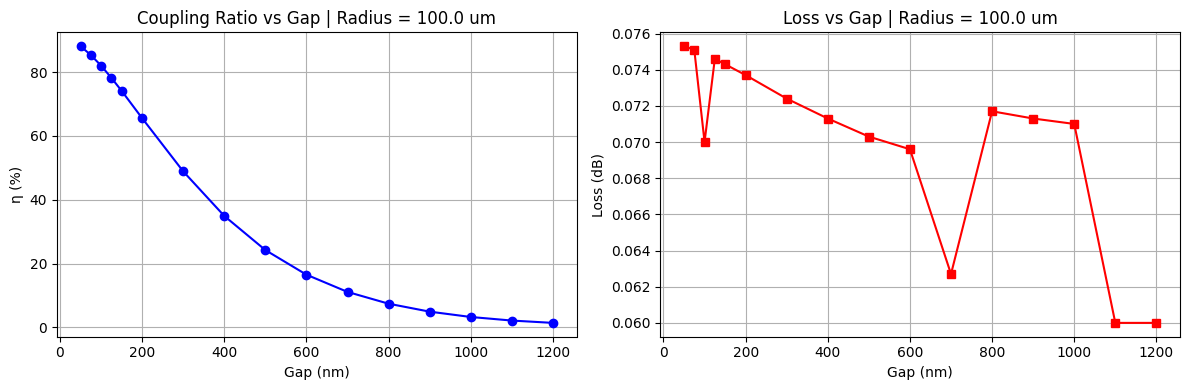

88.1
88.1000000000


In [7]:
import re

# --- Load data from saved files ---
data_dir = Path(r'D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing')
files = sorted(data_dir.glob('*_radius100.0um_gap*nm_Tx.txt'))
pd.set_option('display.precision', 4) 

results = []
for f in files:
    # Gap from filename (most reliable)
    gap_match = re.search(r'gap([\d.]+)nm', f.name)
    if not gap_match:
        continue
    gap = float(gap_match.group(1))
    
    with open(f, 'r') as file:
        header = file.read()
    
    def extract(pattern, text, default=None):
        match = re.search(pattern, text)
        return float(match.group(1)) if match else default
    
    eta = extract(r'eta_1550=([\d.]+)', header)
    loss = extract(r'loss_1550_dB=([\d.-]+)', header)
    eta_var = extract(r'eta_variation=([\d.]+)', header)
    radius  = extract(r'Radius=([\d.]+)',header)
    
    # Skip if missing data
    if None in [eta, loss, eta_var]:
        print(f"Skipping {f.name} — missing data")
        continue
    
    results.append({
        'Gap': gap, 
        'eta_1550(%)': eta * 100, 
        'loss_dB_1550': loss, 
        'eta_variation(%)': eta_var * 100
    })

df = pd.DataFrame(results).drop_duplicates(subset='Gap').sort_values('Gap').reset_index(drop=True)

print(df)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df['Gap'], df['eta_1550(%)'], 'bo-')
axes[0].set_xlabel('Gap (nm)')
axes[0].set_ylabel('η (%)')
axes[0].set_title(f'Coupling Ratio vs Gap | Radius = {radius} um')
axes[0].grid(True)

axes[1].plot(df['Gap'], df['loss_dB_1550'], 'rs-')
axes[1].set_xlabel('Gap (nm)')
axes[1].set_ylabel('Loss (dB)')
axes[1].set_title(f'Loss vs Gap | Radius = {radius} um')
axes[1].grid(True)

# axes[2].plot(df['Gap'], df['eta_variation(%)'], 'g^-')
# axes[2].set_xlabel('Gap (nm)')
# axes[2].set_ylabel('η variation (%)')
# axes[2].set_title('Wavelength Dependence')
# axes[2].grid(True)

plt.tight_layout()
plt.savefig(data_dir / 'gap_sweep_summary.png', dpi=150)
plt.show()

print(df['eta_1550(%)'].iloc[0])  # prints full precision
print(f"{df['eta_1550(%)'].iloc[0]:.10f}")  # force 10 decimals


Text(0, 0.5, 'η (%) - log scale')

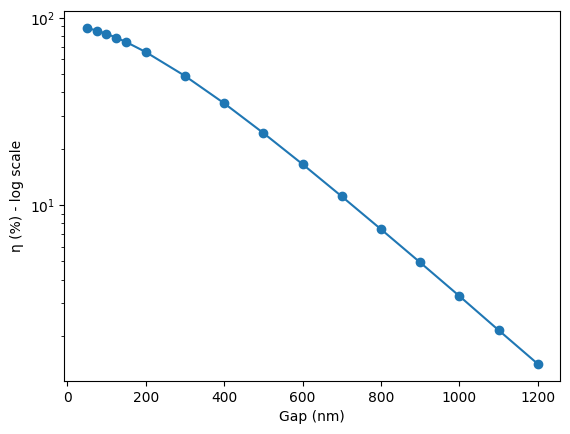

In [8]:
# Should be linear on semilog
plt.semilogy(df['Gap'], df['eta_1550(%)'], 'o-')
plt.xlabel('Gap (nm)')
plt.ylabel('η (%) - log scale')

In [9]:
# η ∝ exp(-Gap/Ld)
from scipy.optimize import curve_fit
popt, _ = curve_fit(lambda g, a, Ld: a * np.exp(-g/Ld), df['Gap'], df['eta_1550(%)'], p0=[80, 300])
print(f"Decay length Ld ≈ {popt[1]:.0f} nm")  # expect ~200-400nm for Si

Decay length Ld ≈ 341 nm


In [ ]:
loss_pct = 1.6

eta_target = 5 * loss_pct
gap_nm = -305 * np.log(eta_target / 75)
eta_escape = eta_target / (eta_target + loss_pct)

print(f"Round-trip loss: {loss_pct:.2f}%")
print(f"Target η (5× loss): {eta_target:.1f}%")
print(f"Required gap: {gap_nm:.0f} nm")
print(f"Escape efficiency: {eta_escape:.1%}")


Round-trip loss: 1.60%
Target η (5× loss): 8.0%
Required gap: 683 nm
Escape efficiency: 83.3%


: 